In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("Dataset loaded successfully!")
print("Features:", X.shape)
print("Target:", y.shape)

Dataset loaded successfully!
Features: (569, 30)
Target: (569,)


In [3]:
print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [4]:
print(X.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [5]:
import pandas as pd

print(pd.Series(y).value_counts())

1    357
0    212
Name: count, dtype: int64


In [6]:
print(data.target_names)

['malignant' 'benign']


In [7]:
print("Missing values:")
print(X.isnull().sum().sum())

Missing values:
0


In [8]:
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [9]:
print("Rows:", X.shape[0])
print("Columns:", X.shape[1])

Rows: 569
Columns: 30


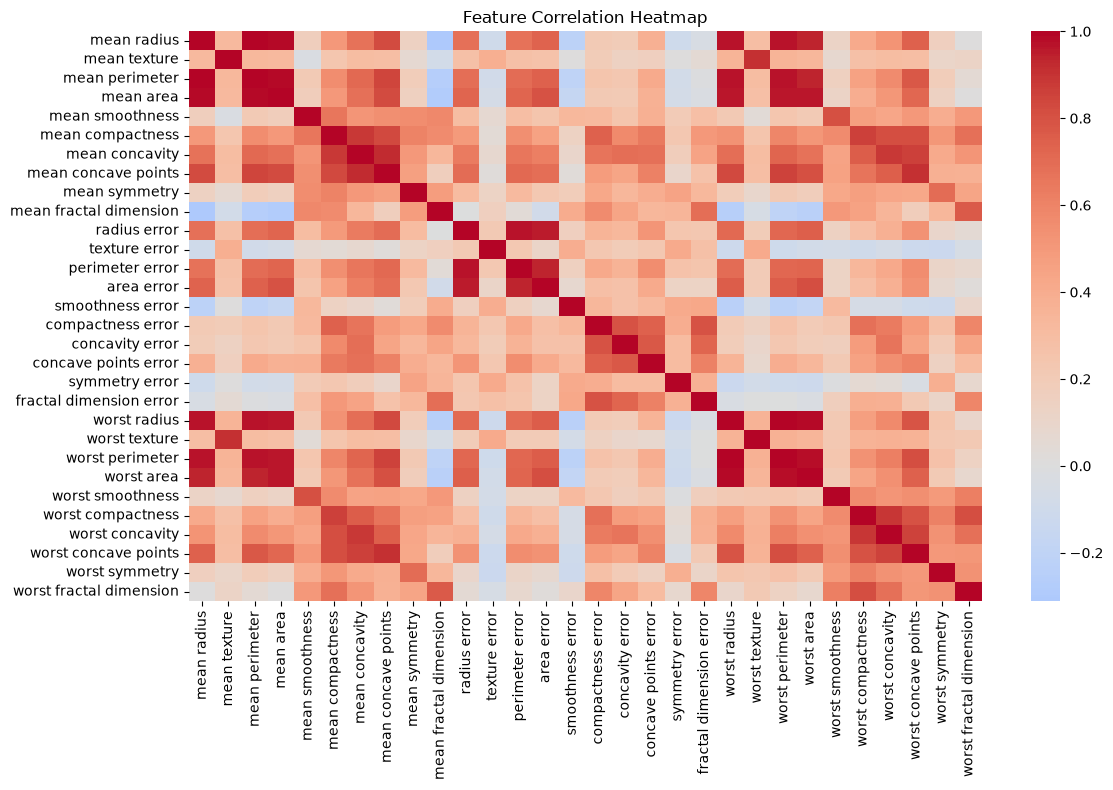

In [10]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:
scaler.fit_transform(X_train)

array([[-1.07200079, -0.6584246 , -1.0880801 , ..., -1.35052668,
        -0.35265805, -0.54138003],
       [ 1.74874285,  0.06650173,  1.75115682, ...,  1.54991557,
         0.19107787, -0.1737386 ],
       [-0.97473376, -0.93112416, -0.99770871, ..., -1.70744192,
        -0.307734  , -1.21303263],
       ...,
       [ 0.39844772,  1.06867262,  0.50751384, ...,  1.53492543,
         0.16164487,  1.23754763],
       [ 0.85331409, -0.0380331 ,  0.9054796 , ...,  2.10455077,
         0.31035897,  0.36249578],
       [-0.91179628, -0.82431683, -0.87666079, ..., -0.51332734,
        -0.50756857,  1.30824791]], shape=(455, 30))

In [15]:
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = model_lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [16]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(y_test, y_pred_lr)

lr_recall = recall_score(y_test, y_pred_lr)

lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
-------------------
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


In [17]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [18]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
-------------
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104


In [19]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

y_pred_gb = gb.predict(X_test)

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [20]:
gb_accuracy = accuracy_score(y_test, y_pred_gb)

gb_precision = precision_score(y_test, y_pred_gb)

gb_recall = recall_score(y_test, y_pred_gb)

gb_f1 = f1_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("-----------------")
print("Accuracy :", gb_accuracy)
print("Precision:", gb_precision)
print("Recall   :", gb_recall)
print("F1 Score :", gb_f1)

Gradient Boosting
-----------------
Accuracy : 0.956140350877193
Precision: 0.9466666666666667
Recall   : 0.9861111111111112
F1 Score : 0.9659863945578231


In [21]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        gb_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Random Forest,0.956140,0.958904,0.972222,0.965517
2,Gradient Boosting,0.956140,0.946667,0.986111,0.965986


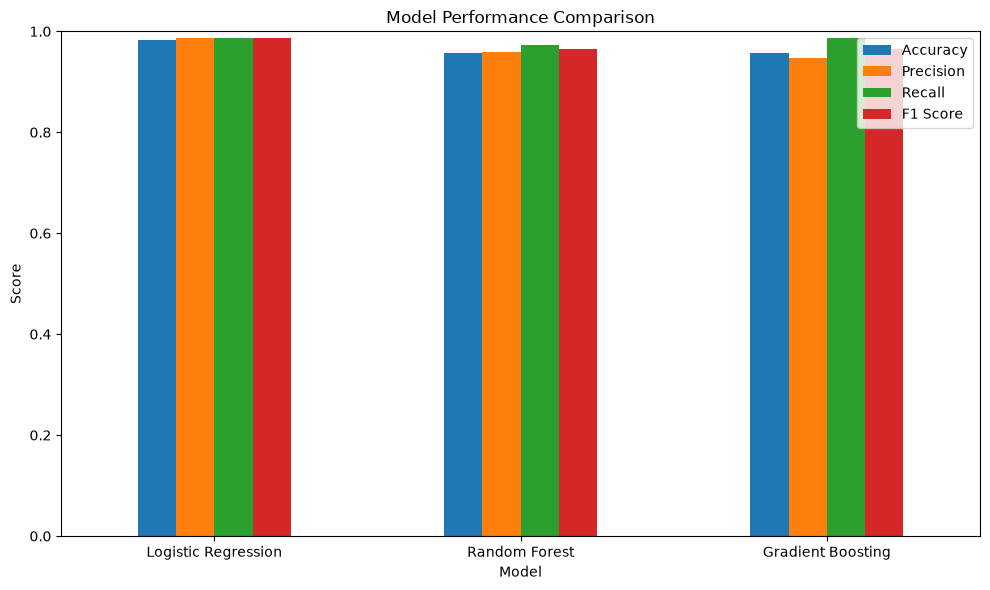

In [22]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 7]
}

In [24]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

In [25]:
grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed

In [26]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 5, 'n_estimators': 100}


In [27]:
print("Best CV Score:")
print(grid.best_score_)

Best CV Score:
0.9633438948791242


In [28]:
best_rf = grid.best_estimator_

In [29]:
y_pred_best_rf = best_rf.predict(X_test)

In [30]:
best_rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

best_rf_precision = precision_score(
    y_test,
    y_pred_best_rf
)

best_rf_recall = recall_score(
    y_test,
    y_pred_best_rf
)

best_rf_f1 = f1_score(
    y_test,
    y_pred_best_rf
)

print("Optimized Random Forest")
print("-----------------------")
print("Accuracy :", best_rf_accuracy)
print("Precision:", best_rf_precision)
print("Recall   :", best_rf_recall)
print("F1 Score :", best_rf_f1)


Optimized Random Forest
-----------------------
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104


In [31]:
cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("Mean CV Accuracy:")
print(cv_scores.mean())

print("Standard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.96703297 0.98901099 0.92307692 0.92307692 0.94505495]
Mean CV Accuracy:
0.9494505494505496
Standard Deviation:
0.025630557779539775


In [32]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance.head(10))

worst area              0.138294
worst concave points    0.132993
worst radius            0.100805
mean concave points     0.098489
worst perimeter         0.072224
mean perimeter          0.068612
mean radius             0.067465
mean concavity          0.057445
mean area               0.050615
worst concavity         0.031544
dtype: float64


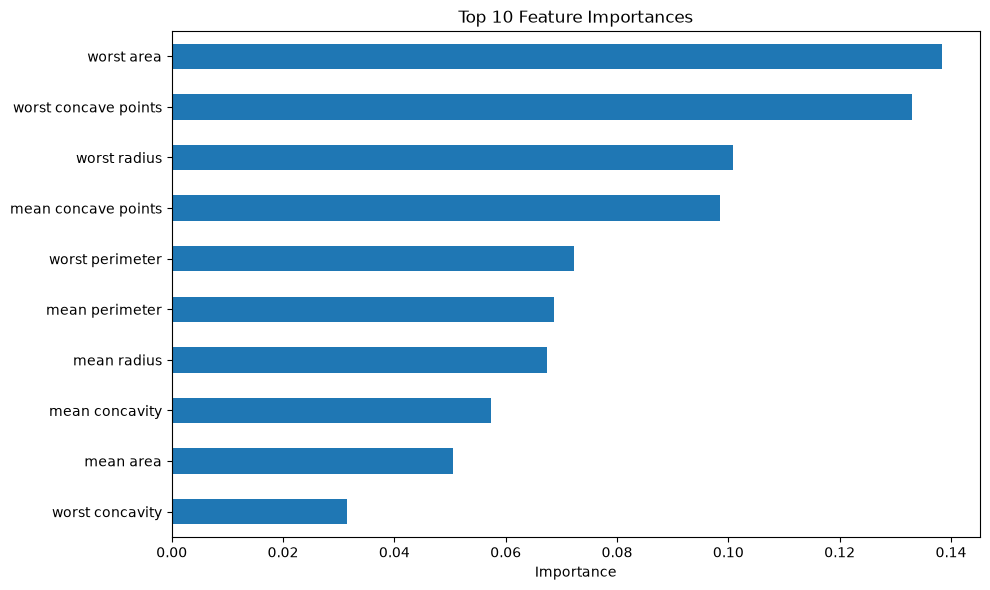

In [33]:
plt.figure(figsize=(10, 6))

importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

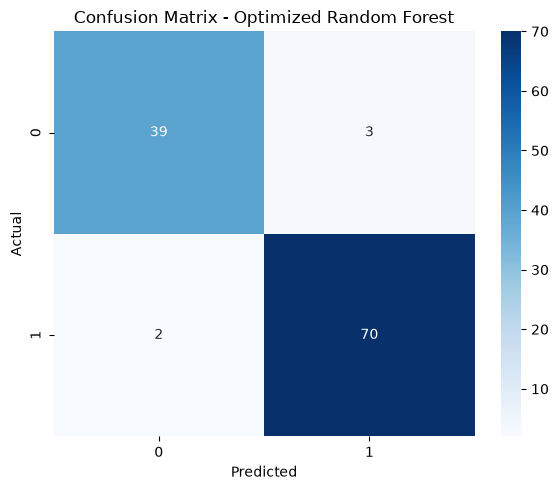

In [34]:
cm = confusion_matrix(
    y_test,
    y_pred_best_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Optimized Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [35]:
sample = X_test.iloc[[0]]

prediction = best_rf.predict(sample)

print("Predicted class:", prediction[0])
print("Actual class:", y_test[0])

Predicted class: 0
Actual class: 0


In [36]:
print(
    "Predicted:",
    data.target_names[prediction[0]]
)

print(
    "Actual:",
    data.target_names[y_test[0]]
)

Predicted: malignant
Actual: malignant


In [37]:
joblib.dump(
    best_rf,
    "models/best_model.pkl"
)

['models/best_model.pkl']

In [38]:
joblib.dump(
    scaler,
    "models/scaler.pkl"
)

['models/scaler.pkl']

In [39]:
results.to_csv(
    "model_results.csv",
    index=False
)